In [131]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [132]:
df = pd.read_csv("workout.csv")

df.head(3)

,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01,110,130,409.1
1,60,2020/12/02,117,145,479.0
2,60,2020/12/03,103,135,340.0


In [133]:
df.shape
df.columns
df.info()
df.isnull().sum()
df.drop_duplicates()



<class 'pandas.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      32 non-null     str    
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), str(1)
memory usage: 1.4 KB


,Duration,Date,Pulse,Maxpulse,Calories
0,60,2020/12/01,110,130,409.1
1,60,2020/12/02,117,145,479.0
2,60,2020/12/03,103,135,340.0
3,45,2020/12/04,109,175,282.4
4,45,2020/12/05,117,148,406.0
5,60,2020/12/06,102,127,300.0
6,60,2020/12/07,110,136,374.0
7,450,2020/12/08,104,134,253.3
8,30,2020/12/09,109,133,195.1
9,60,2020/12/10,98,124,269.0


### Workout Dataset Analysis Questions

What is the typical duration of a workout session in this dataset?

In [134]:
duration = df['Duration'].mean()
print(f"The typical duration of a workout session is {duration.round(2)}")

The typical duration of a workout session is 68.44


How many calories are burned on average during a workout?

In [135]:
avg_cal= df[df['Calories']>0]["Calories"].mean().round(2)
print(f"Calories burned on average during a workout is {avg_cal}")

Calories burned on average during a workout is 304.68


Which workout session burned the highest number of calories?

In [136]:
session = df["Calories"].argmax()
df.iloc[session]

Duration            60
Date        2020/12/02
Pulse              117
Maxpulse           145
Calories         479.0
Name: 1, dtype: object

Which workout session had the highest recorded pulse rate?

In [137]:
session = df["Pulse"].argmax()
df.iloc[session]

Duration            60
Date        2020/12/23
Pulse              130
Maxpulse           101
Calories         300.0
Name: 23, dtype: object

What is the overall distribution of workout durations?

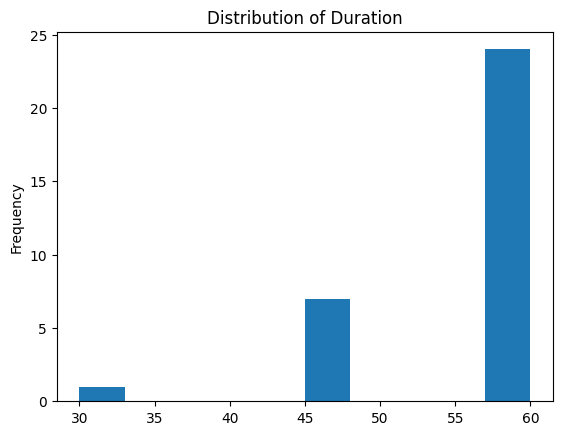

In [138]:
#Fixing the error of 450 to 45
df.loc[7,"Duration"] = int(45)
df['Duration'].plot(kind='hist')
plt.title("Distribution of Duration")
plt.show()

Are most workouts short, medium, or long in duration?

<Axes: xlabel='Category', ylabel='Duration'>

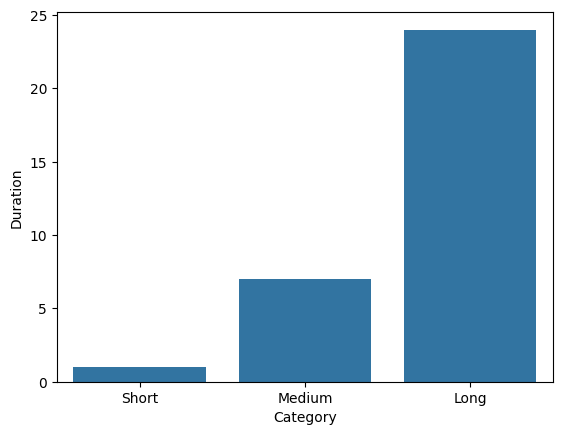

In [139]:
short = df[df["Duration"]<35]["Duration"].count()
medium = df[(df["Duration"]>=35) & (df["Duration"]<55)]["Duration"].count()
long = df[df["Duration"]>55]["Duration"].count()

workouts = pd.DataFrame(
         { "Category": ["Short", "Medium", "Long"],
           "Duration": [short,medium,long] 
         }
)

sns.barplot(data= workouts, x= "Category", y= "Duration")

Do longer workouts consistently result in higher calorie expenditure?

<Axes: xlabel='Duration', ylabel='Calories'>

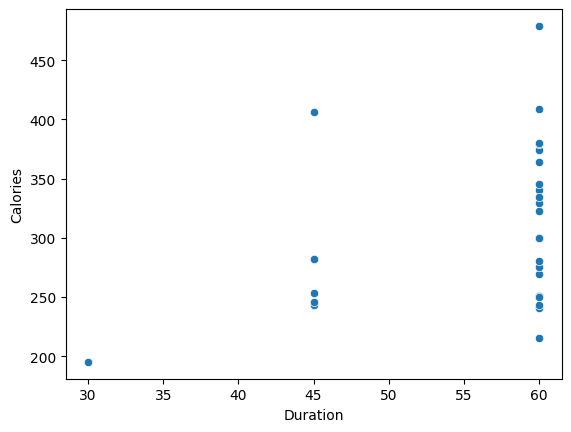

In [140]:
df.loc[df["Calories"].isna(),"Calories"] = df["Calories"].mode()
sns.scatterplot(data= df, x= "Duration", y = "Calories")

How does pulse rate vary across different workout durations?

<Axes: xlabel='Duration', ylabel='Pulse'>

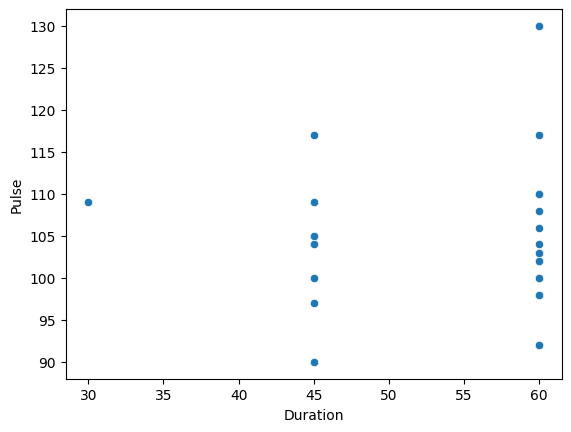

In [141]:
sns.scatterplot(data= df, x= "Duration", y = "Pulse")

Is a higher pulse associated with more calories burned?

<Axes: xlabel='Pulse', ylabel='Calories'>

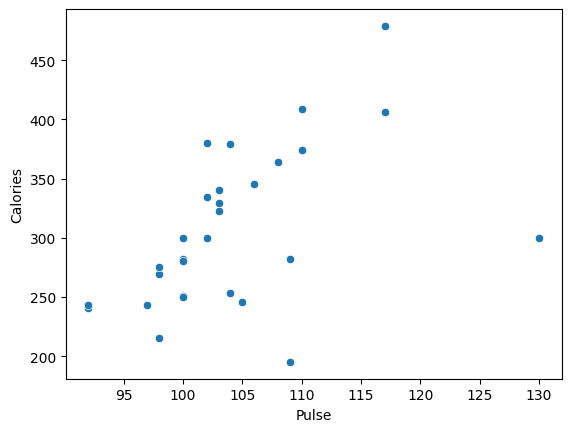

In [142]:
sns.scatterplot(data =df,x="Pulse",y="Calories")

What is the relationship between pulse and maximum pulse?

<Axes: xlabel='Pulse', ylabel='Maxpulse'>

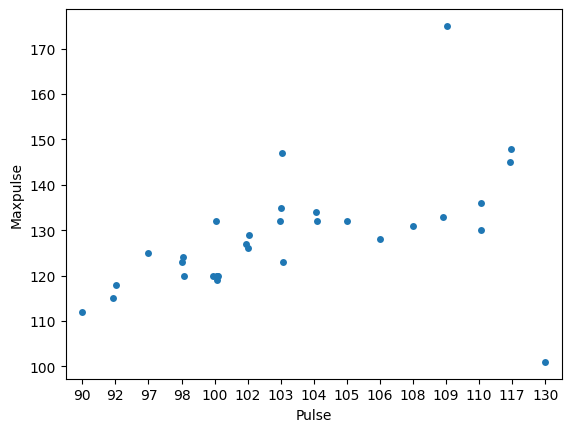

In [143]:
sns.stripplot(data=df, x= "Pulse", y="Maxpulse")

Which variable appears to have the strongest influence on calories burned?

In [144]:
df.corr(numeric_only=True)["Calories"].sort_values(ascending=False)

Calories    1.000000
Pulse       0.513186
Maxpulse    0.357460
Duration    0.335571
Name: Calories, dtype: float64

Are there any unusual workout sessions that differ significantly from the rest?

<Axes: >

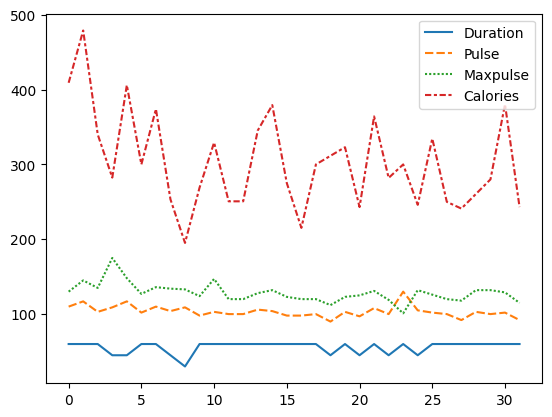

In [145]:
sns.lineplot(df)

How does workout intensity vary across different dates?

<Axes: xlabel='Calories', ylabel='Date'>

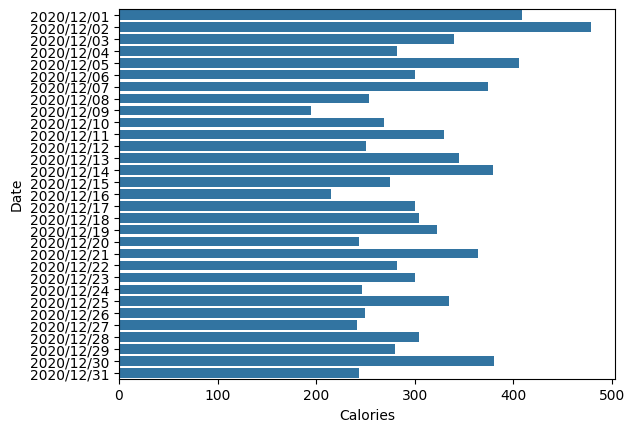

In [160]:
df.loc[df["Date"] == "20201226","Date"] = "2020/12/22"
df.loc[df["Calories"].isna(),"Calories"] = df["Calories"].mean()
sns.barplot(data=df, y= "Date" , x= "Calories")

Are calorie-burning patterns consistent over time?

<Axes: xlabel='Day', ylabel='Calories'>

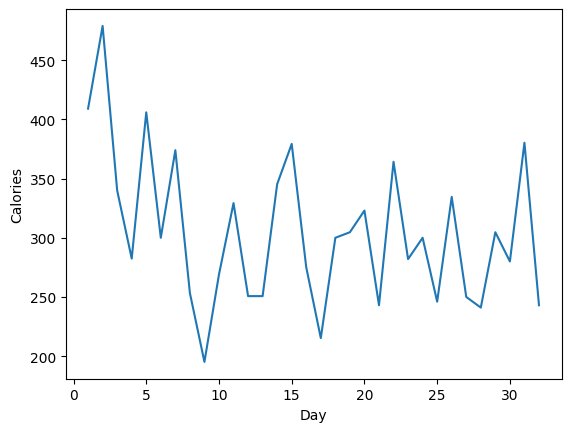

In [161]:
df["Day"] = (df.index).astype(int)+1
sns.lineplot(data= df, y= "Calories", x="Day")

Which date recorded the most demanding workout session?

In [165]:
df.iloc[df['Calories'].idxmax()]["Date"]

'2020/12/02'

What trends can be observed in workout performance throughout the recorded period?

<Axes: >

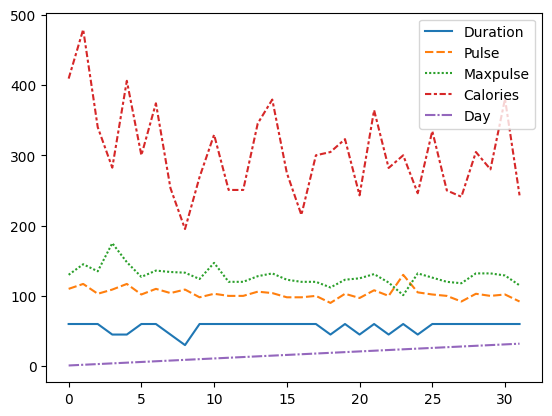

In [166]:
sns.lineplot(df)

Are there any periods where workout intensity noticeably increased or decreased?

<Axes: xlabel='Day', ylabel='Pulse'>

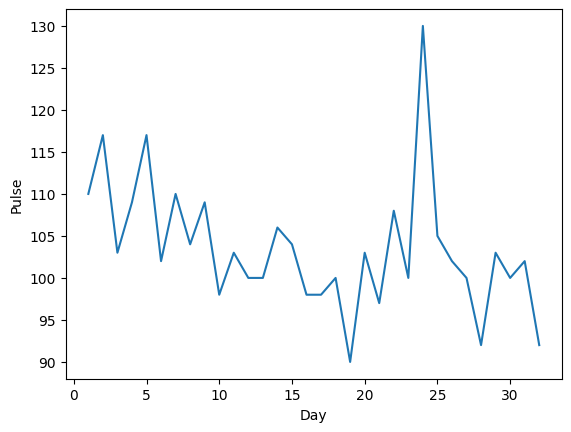

In [168]:
sns.lineplot(data=df , y= "Pulse" , x= "Day")

Which workouts appear to be the most efficient in terms of calories burned relative to duration?

In [172]:
df["CpM"] = df["Calories"] / df["Duration"]
df.iloc[df["CpM"].argmax()]

Duration            45
Date        2020/12/05
Pulse              117
Maxpulse           148
Calories         406.0
Day                  5
CpM           9.022222
Name: 4, dtype: object

What key insights can be derived to improve workout planning and performance?